In [1]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

# Clustering
from sklearn.cluster import KMeans

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("squads.csv")

print(df.head())
print(df.info())

   key_id tournament_id            tournament_name team_id  team_name  \
0       1       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
1       2       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
2       3       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
3       4       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
4       5       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   

  team_code player_id  family_name given_name  shirt_number position_name  \
0       ARG   P-69244       Bossio      Ángel             0   goal keeper   
1       ARG   P-23160      Botasso       Juan             0   goal keeper   
2       ARG   P-99230       Cherro    Roberto             0       forward   
3       ARG   P-41921    Chividini    Alberto             0      defender   
4       ARG   P-22739  Della Torre       José             0      defender   

  position_code  
0            GK  
1            GK  
2            FW  
3            DF  
4       

In [3]:
# Drop missing values (you can improve this later with imputation)
df = df.dropna()

# Check columns
print(df.columns)

Index(['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name',
       'team_code', 'player_id', 'family_name', 'given_name', 'shirt_number',
       'position_name', 'position_code'],
      dtype='str')


In [5]:
if text_column not in df.columns:
    print("Available columns:", df.columns)

Available columns: Index(['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name',
       'team_code', 'player_id', 'family_name', 'given_name', 'shirt_number',
       'position_name', 'position_code'],
      dtype='str')


In [6]:
df.columns = df.columns.str.lower().str.strip()
text_column = "description"

In [9]:
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.copy()

print(X.head())
print(X.shape)

   key_id  shirt_number
0       1             0
1       2             0
2       3             0
3       4             0
4       5             0
(13843, 2)


In [11]:
print(df.head())
print(df.columns)

   key_id tournament_id            tournament_name team_id  team_name  \
0       1       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
1       2       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
2       3       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
3       4       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   
4       5       WC-1930  1930 FIFA Men's World Cup    T-03  Argentina   

  team_code player_id  family_name given_name  shirt_number position_name  \
0       ARG   P-69244       Bossio      Ángel             0   goal keeper   
1       ARG   P-23160      Botasso       Juan             0   goal keeper   
2       ARG   P-99230       Cherro    Roberto             0       forward   
3       ARG   P-41921    Chividini    Alberto             0      defender   
4       ARG   P-22739  Della Torre       José             0      defender   

  position_code  
0            GK  
1            GK  
2            FW  
3            DF  
4       

In [14]:
print(df.columns)

Index(['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name',
       'team_code', 'player_id', 'family_name', 'given_name', 'shirt_number',
       'position_name', 'position_code'],
      dtype='str')


In [18]:
df.head()

,key_id,tournament_id,tournament_name,team_id,team_name,team_code,player_id,family_name,given_name,shirt_number,position_name,position_code
0,1,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,P-69244,Bossio,Ángel,0,goal keeper,GK
1,2,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,P-23160,Botasso,Juan,0,goal keeper,GK
2,3,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,P-99230,Cherro,Roberto,0,forward,FW
3,4,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,P-41921,Chividini,Alberto,0,defender,DF
4,5,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,P-22739,Della Torre,José,0,defender,DF


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print(df["cluster"].value_counts())

cluster
0    5413
2    4281
1    4149
Name: count, dtype: int64


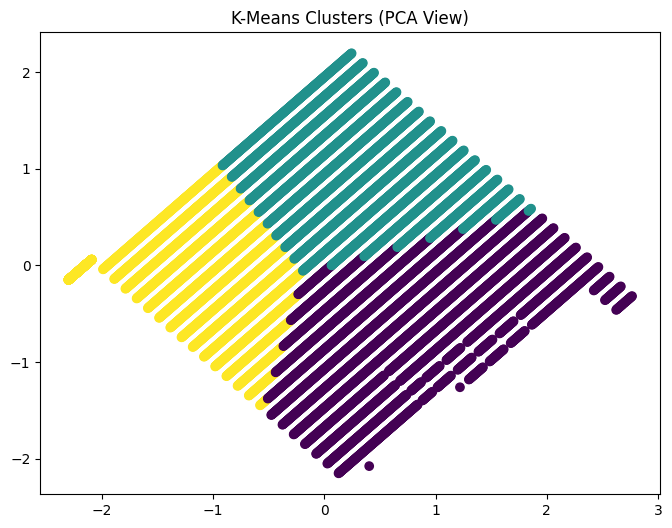

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], c=clusters, cmap="viridis")
plt.title("K-Means Clusters (PCA View)")
plt.show()

In [27]:
print(df.columns)

Index(['key_id', 'tournament_id', 'tournament_name', 'team_id', 'team_name',
       'team_code', 'player_id', 'family_name', 'given_name', 'shirt_number',
       'position_name', 'position_code', 'cluster'],
      dtype='str')
